# NOTE: This notebook uses local fallback paths for exploratory analysis.
# Production pipeline runs via run_pipeline.py or the Airflow DAG.



# Stage 3 — Transform: Standard 2SFCA Accessibility Model

This notebook explains and explores the **Two-Step Floating Catchment Area (2SFCA)** method (Luo & Wang, 2003) with Gaussian distance decay.

### Algorithm

**Step 1 — Supply ratio at each facility j:**

$$R_j = \frac{S_j}{\sum_{i: d_{ij} \leq d_0} P_i \cdot W(d_{ij})}$$

**Step 2 — Accessibility score at each block i:**

$$A_i = \sum_{j: d_{ij} \leq d_0} R_j \cdot W(d_{ij})$$

**Gaussian decay weight:**

$$W(d) = e^{-(d / d_0)^2}$$

Where $d_0$ = 900 m catchment radius, $S_j$ = bed count, $P_i$ = population.

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# No pipeline imports — standalone notebook
Blocks_DC = "../data/intermediate_files/blocks_Washington_DC.shp"
ICF   = "../data/intermediate_files/ICFs_DC.shp"
CRS  = "EPSG:26985"
D0   = 900      # catchment radius in metres

# Load and prepare blocks
blocks = gpd.read_file(Blocks_DC).to_crs(CRS)
pop_gdf = blocks.rename(columns={"GEOCODE": "GEOID", "Total Popu": "population"}).copy()
pop_gdf["population"] = pd.to_numeric(pop_gdf["population"], errors="coerce").fillna(0).astype(int)
pop_gdf = pop_gdf[pop_gdf.geometry.is_valid].reset_index(drop=True)

# Load and prepare facilities
facs = gpd.read_file(ICF).to_crs(CRS)
fac_gdf = facs.rename(columns={"NAME": "FAC_NAME", "BEDS": "CRTFD_BED_CNT"}).copy()
fac_gdf["CRTFD_BED_CNT"] = pd.to_numeric(fac_gdf["CRTFD_BED_CNT"], errors="coerce").fillna(0).astype(int)
fac_gdf = fac_gdf[fac_gdf["CRTFD_BED_CNT"] > 0].reset_index(drop=True)

print(f"Population blocks : {len(pop_gdf):,}")
print(f"ICF facilities    : {len(fac_gdf)}")
print(f"Catchment radius  : {D0} m")

Population blocks : 6,012
ICF facilities    : 114
Catchment radius  : 900 m


## 1. Distance Analysis — How far are blocks from facilities?

Blocks within 900m of nearest facility : 3,728 (62.0%)
Mean distance to nearest facility       : 976 m
Max distance to nearest facility        : 4671 m


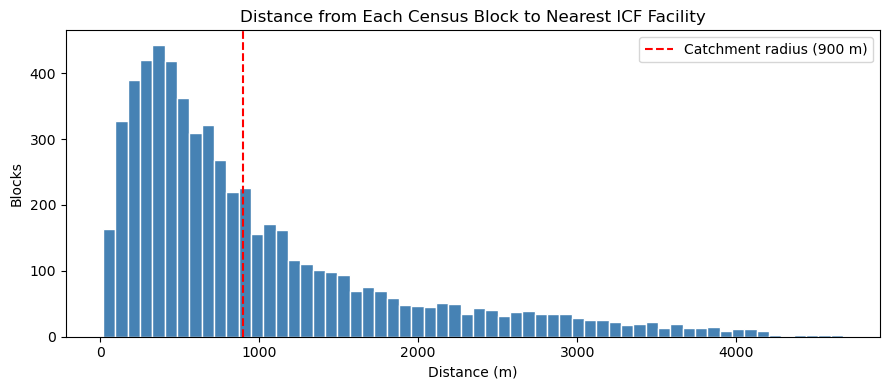

In [4]:
pop_xy = np.column_stack([pop_gdf.geometry.centroid.x, pop_gdf.geometry.centroid.y])
fac_xy = np.column_stack([fac_gdf.geometry.centroid.x, fac_gdf.geometry.centroid.y])

fac_tree = cKDTree(fac_xy)
nearest_dist, _ = fac_tree.query(pop_xy, k=1)

within = (nearest_dist <= D0).sum()
print(f"Blocks within {D0}m of nearest facility : {within:,} ({within/len(pop_gdf)*100:.1f}%)")
print(f"Mean distance to nearest facility       : {nearest_dist.mean():.0f} m")
print(f"Max distance to nearest facility        : {nearest_dist.max():.0f} m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nearest_dist, bins=60, color="steelblue", edgecolor="white")
ax.axvline(D0, color="red", linestyle="--", label=f"Catchment radius ({D0} m)")
ax.set_title("Distance from Each Census Block to Nearest ICF Facility")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Blocks")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/eda_04_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Gaussian Decay Weight Visualisation

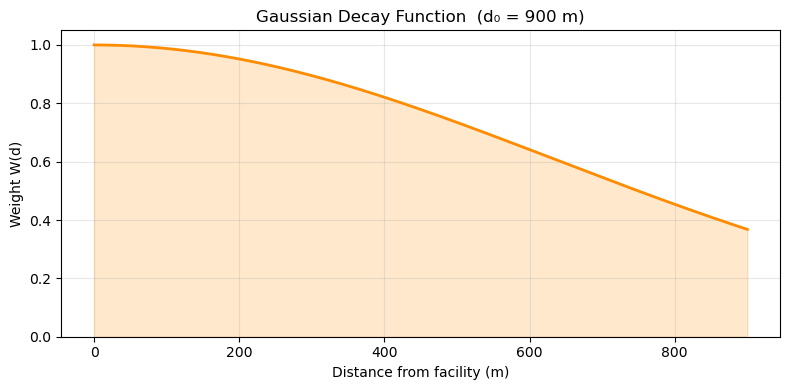

In [6]:
d = np.linspace(0, D0, 300)
w = np.exp(-((d / D0) ** 2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(d, w, color="darkorange", linewidth=2)
ax.fill_between(d, w, alpha=0.2, color="darkorange")
ax.set_title(f"Gaussian Decay Function  (d₀ = {D0} m)")
ax.set_xlabel("Distance from facility (m)")
ax.set_ylabel("Weight W(d)")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/eda_04_gaussian_decay.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Compute 2SFCA Step by Step

In [7]:
pop_xy = np.column_stack([pop_gdf.geometry.centroid.x, pop_gdf.geometry.centroid.y])
fac_xy = np.column_stack([fac_gdf.geometry.centroid.x, fac_gdf.geometry.centroid.y])
pop_vals = pop_gdf["population"].values.astype(float)
bed_vals  = fac_gdf["CRTFD_BED_CNT"].values.astype(float)

fac_tree = cKDTree(fac_xy)
pop_tree = cKDTree(pop_xy)

# Step 1 — supply ratio R_j at each facility
R = np.zeros(len(fac_gdf))
for j, (fxy, beds) in enumerate(zip(fac_xy, bed_vals)):
    idx = pop_tree.query_ball_point(fxy, D0)
    if not idx:
        continue
    dists = np.linalg.norm(pop_xy[idx] - fxy, axis=1)
    weights = np.exp(-((dists / D0) ** 2))
    demand = np.dot(pop_vals[idx], weights)
    R[j] = beds / demand if demand > 0 else 0

# Step 2 — accessibility score A_i at each census block
A = np.zeros(len(pop_gdf))
for i, pxy in enumerate(pop_xy):
    idx = fac_tree.query_ball_point(pxy, D0)
    if not idx:
        continue
    dists = np.linalg.norm(fac_xy[idx] - pxy, axis=1)
    weights = np.exp(-((dists / D0) ** 2))
    A[i] = np.dot(R[idx], weights)

# Attach scores to GeoDataFrame
result_gdf = pop_gdf.copy()
result_gdf["accessibility_score"] = A
max_score = A.max()
result_gdf["accessibility_norm"] = A / max_score if max_score > 0 else 0

print(result_gdf[["GEOID", "population", "accessibility_score", "accessibility_norm"]].head(10).to_string())

             GEOID  population  accessibility_score  accessibility_norm
0  110010001021004        3318             0.000000            0.000000
1  110010001021006        3318             0.000000            0.000000
2  110010001021001        3318             0.000000            0.000000
3  110010014023009        3476             0.000000            0.000000
4  110010024001009        4061             0.000029            0.075936
5  110010041001005        2466             0.000000            0.000000
6  110010082001003        3234             0.000005            0.013111
7  110010030002000        4211             0.000020            0.052939
8  110010044011006        3522             0.000000            0.000000
9  110010073011032        5031             0.000000            0.000000


## 4. Accessibility Score Distribution

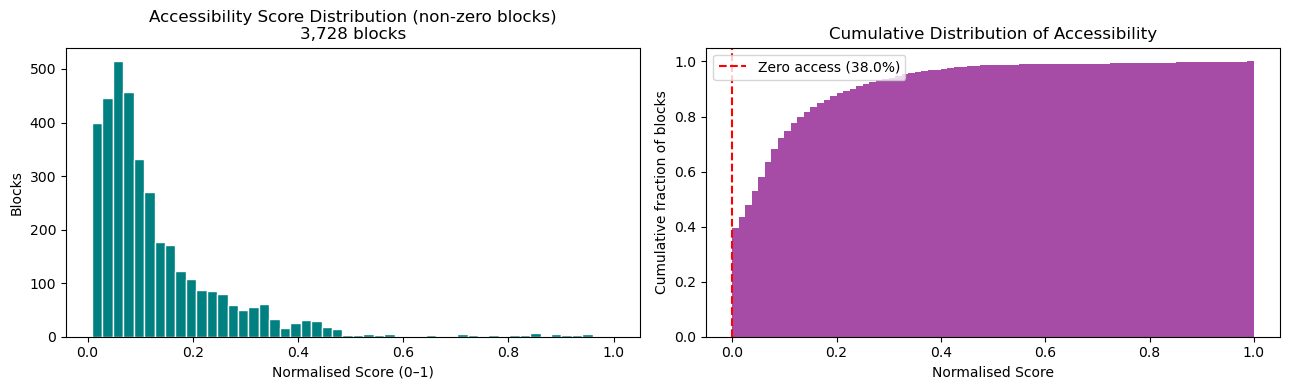


Mean score        : 0.0841
Median score      : 0.0430
Zero-access blocks: 2,284 (38.0%)


In [8]:
scores = result_gdf["accessibility_norm"]
zero_pct = (scores == 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nonzero = scores[scores > 0]
axes[0].hist(nonzero, bins=50, color="teal", edgecolor="white")
axes[0].set_title(f"Accessibility Score Distribution (non-zero blocks)\n{len(nonzero):,} blocks")
axes[0].set_xlabel("Normalised Score (0–1)")
axes[0].set_ylabel("Blocks")

axes[1].hist(scores, bins=80, cumulative=True, density=True, color="purple", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", label=f"Zero access ({zero_pct:.1f}%)")
axes[1].set_title("Cumulative Distribution of Accessibility")
axes[1].set_xlabel("Normalised Score")
axes[1].set_ylabel("Cumulative fraction of blocks")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/eda_04_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMean score        : {scores.mean():.4f}")
print(f"Median score      : {scores.median():.4f}")
print(f"Zero-access blocks: {(scores == 0).sum():,} ({zero_pct:.1f}%)")

## 5. Population vs Accessibility — Is there spatial inequity?

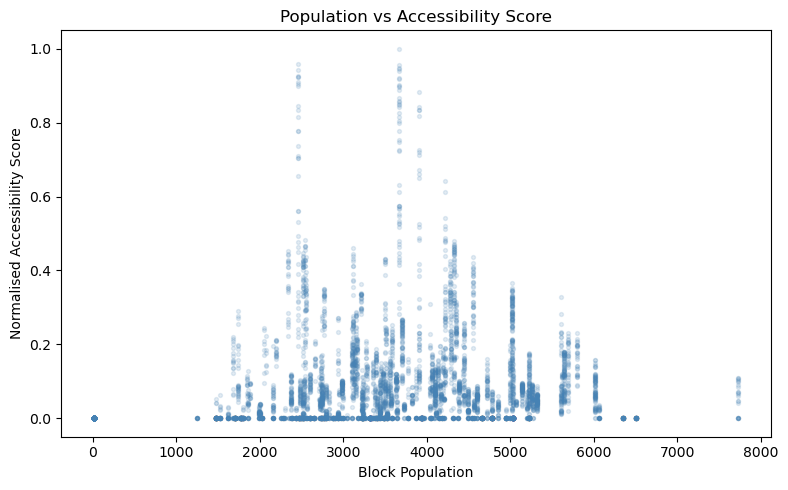

Pearson correlation (population vs accessibility): 0.0976


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    result_gdf["population"],
    result_gdf["accessibility_norm"],
    alpha=0.15, s=8, color="steelblue"
)
ax.set_title("Population vs Accessibility Score")
ax.set_xlabel("Block Population")
ax.set_ylabel("Normalised Accessibility Score")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_04_population_vs_access.png", dpi=150, bbox_inches="tight")
plt.show()

corr = result_gdf[["population", "accessibility_norm"]].corr().iloc[0, 1]
print(f"Pearson correlation (population vs accessibility): {corr:.4f}")